In [1]:
import numpy as np

In [2]:
## Importing Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [3]:
## Loading Data

train_data = pd.read_excel(r'C:\Users\princi\Downloads\PBEL12\Data\Data_Train.xlsx')

In [4]:
test_data = pd.read_excel(r"C:\Users\princi\Downloads\PBEL12\Data\Test_set.xlsx")

In [5]:
pd.set_option('display.max_columns', None)

In [6]:
train_data

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302
...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648


In [7]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [8]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2671 entries, 0 to 2670
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          2671 non-null   object
 1   Date_of_Journey  2671 non-null   object
 2   Source           2671 non-null   object
 3   Destination      2671 non-null   object
 4   Route            2671 non-null   object
 5   Dep_Time         2671 non-null   object
 6   Arrival_Time     2671 non-null   object
 7   Duration         2671 non-null   object
 8   Total_Stops      2671 non-null   object
 9   Additional_Info  2671 non-null   object
dtypes: object(10)
memory usage: 208.8+ KB


In [9]:
#duplicate
train_data.duplicated().sum()

np.int64(220)

In [10]:
test_data.duplicated().sum()

np.int64(26)

In [11]:
## both the train and test data have duplicate records in tyhem but it is possible in tyhis case so do not remove it 

In [13]:
#missing values

In [12]:
train_data.isnull().sum() #only 1 missing value route and total_stops in train data

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

In [14]:
# Removing the null values from training data 

In [15]:
train_data.dropna(inplace=True)

In [16]:
print(train_data.isnull().sum())
print("***" * 25)
print(test_data.isnull().sum())

# train and test data have 0 missing values

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              0
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        0
Additional_Info    0
Price              0
dtype: int64
***************************************************************************
Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              0
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        0
Additional_Info    0
dtype: int64


In [17]:
print(train_data.shape)

(10682, 11)


In [18]:
## Not extracting the year since the data is from 2019 only

# Convert Date_of_Journey to datetime
train_data['Date_of_Journey'] = pd.to_datetime(
    train_data['Date_of_Journey'], format='%d/%m/%Y'
)

test_data['Date_of_Journey'] = pd.to_datetime(
    test_data['Date_of_Journey'], format='%d/%m/%Y'
)

# Extract day and month from Date_of_Journey
train_data['Journey_Day'] = train_data['Date_of_Journey'].dt.day
train_data['Journey_Month'] = train_data['Date_of_Journey'].dt.month

test_data['Journey_Day'] = test_data['Date_of_Journey'].dt.day
test_data['Journey_Month'] = test_data['Date_of_Journey'].dt.month

In [19]:
train_data

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Journey_Day,Journey_Month
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,1,5
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882,9,6
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218,12,5
4,IndiGo,2019-03-01,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,2019-04-09,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107,9,4
10679,Air India,2019-04-27,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145,27,4
10680,Jet Airways,2019-04-27,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229,27,4
10681,Vistara,2019-03-01,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648,1,3


In [20]:
# 2. Departure Time and 3. Arrival Time

train_data['Dep_Time'] = pd.to_datetime(train_data['Dep_Time'])
train_data['Arrival_Time'] = pd.to_datetime(train_data['Arrival_Time'])

test_data['Dep_Time'] = pd.to_datetime(test_data['Dep_Time'])
test_data['Arrival_Time'] = pd.to_datetime(test_data['Arrival_Time'])

train_data

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Journey_Day,Journey_Month
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,2026-07-11 22:20:00,2026-03-22 01:10:00,2h 50m,non-stop,No info,3897,24,3
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,2026-07-11 05:50:00,2026-07-11 13:15:00,7h 25m,2 stops,No info,7662,1,5
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,2026-07-11 09:25:00,2026-06-10 04:25:00,19h,2 stops,No info,13882,9,6
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,2026-07-11 18:05:00,2026-07-11 23:30:00,5h 25m,1 stop,No info,6218,12,5
4,IndiGo,2019-03-01,Banglore,New Delhi,BLR → NAG → DEL,2026-07-11 16:50:00,2026-07-11 21:35:00,4h 45m,1 stop,No info,13302,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,2019-04-09,Kolkata,Banglore,CCU → BLR,2026-07-11 19:55:00,2026-07-11 22:25:00,2h 30m,non-stop,No info,4107,9,4
10679,Air India,2019-04-27,Kolkata,Banglore,CCU → BLR,2026-07-11 20:45:00,2026-07-11 23:20:00,2h 35m,non-stop,No info,4145,27,4
10680,Jet Airways,2019-04-27,Banglore,Delhi,BLR → DEL,2026-07-11 08:20:00,2026-07-11 11:20:00,3h,non-stop,No info,7229,27,4
10681,Vistara,2019-03-01,Banglore,New Delhi,BLR → DEL,2026-07-11 11:30:00,2026-07-11 14:10:00,2h 40m,non-stop,No info,12648,1,3


In [21]:
# Extract hour and minute from Dep_Time and Arrival_Time
train_data['Dep_Hour'] = train_data['Dep_Time'].dt.hour
train_data['Dep_Minute'] = train_data['Dep_Time'].dt.minute

train_data['Arrival_Hour'] = train_data['Arrival_Time'].dt.hour
train_data['Arrival_Minute'] = train_data['Arrival_Time'].dt.minute

test_data['Dep_Hour'] = test_data['Dep_Time'].dt.hour
test_data['Dep_Minute'] = test_data['Dep_Time'].dt.minute

test_data['Arrival_Hour'] = test_data['Arrival_Time'].dt.hour
test_data['Arrival_Minute'] = test_data['Arrival_Time'].dt.minute

# Drop Dep_Time and Arrival_Time as they are now redundant
train_data.drop(['Dep_Time', 'Arrival_Time'], axis=1, inplace=True)
test_data.drop(['Dep_Time', 'Arrival_Time'], axis=1, inplace=True)

In [22]:
# 4. Duration

# Handling Duration feature
def convert_duration(duration):
    duration = duration.split()
    hours = 0
    minutes = 0
    for d in duration:
        if 'h' in d:
            hours = int(d[:-1])
        elif 'm' in d:
            minutes = int(d[:-1])
    return hours * 60 + minutes

train_data['Duration'] = train_data['Duration'].apply(convert_duration)
test_data['Duration'] = test_data['Duration'].apply(convert_duration)

In [23]:
# 5. Creating a new feature "Journey Day" (monday = 0, tuesday = 1, ...... sunday = 6)

# Journey Day of Week
train_data['Journey_Day_of_Week'] = train_data.apply(
    lambda row: pd.Timestamp(year=2019, month=row['Journey_Month'], 
                              day=row['Journey_Day']).dayofweek, axis=1)

test_data['Journey_Day_of_Week'] = test_data.apply(
    lambda row: pd.Timestamp(year=2019, month=row['Journey_Month'], 
                              day=row['Journey_Day']).dayofweek, axis=1)

In [24]:
train_data['Journey_Day_of_Week'].value_counts()

Journey_Day_of_Week
2    2079
0    1849
3    1832
5    1670
6    1474
4     909
1     869
Name: count, dtype: int64

In [25]:
# 6. Creating a new feature - whether the day of journey was weekend or not

# Is Weekend
train_data['Is_Weekend'] = train_data['Journey_Day_of_Week'].apply(lambda x: 1 if x >= 5 else 0)
test_data['Is_Weekend'] = test_data['Journey_Day_of_Week'].apply(lambda x: 1 if x >= 5 else 0)

In [26]:
def part_of_day(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

In [27]:
# Departure Part of the Day
train_data['Dep_Part_of_Day'] = train_data['Dep_Hour'].apply(part_of_day)
test_data['Dep_Part_of_Day'] = test_data['Dep_Hour'].apply(part_of_day)

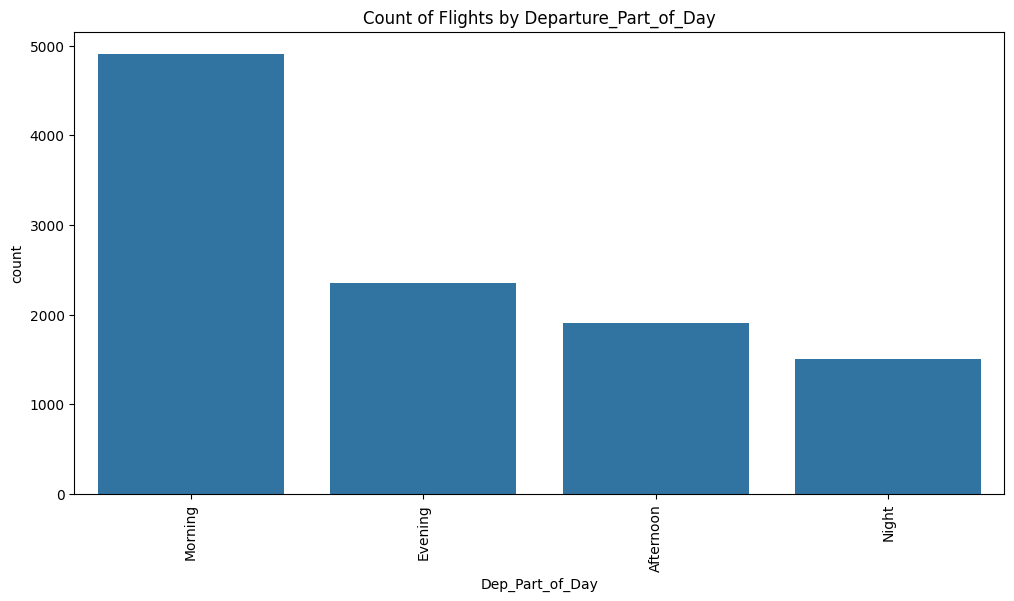

In [28]:
# Dep_Part_of_Day feature distribution
plt.figure(figsize=(12, 6))
sns.countplot(data=train_data, x='Dep_Part_of_Day', order=train_data['Dep_Part_of_Day'].value_counts().index)
plt.title('Count of Flights by Departure_Part_of_Day')
plt.xticks(rotation=90)
plt.show()

# Dep_Part_of_Day feature dependence on Price

In [29]:
train_data['Dep_Part_of_Day'] = train_data['Dep_Hour'].apply(part_of_day)
test_data['Dep_Part_of_Day'] = test_data['Dep_Hour'].apply(part_of_day)

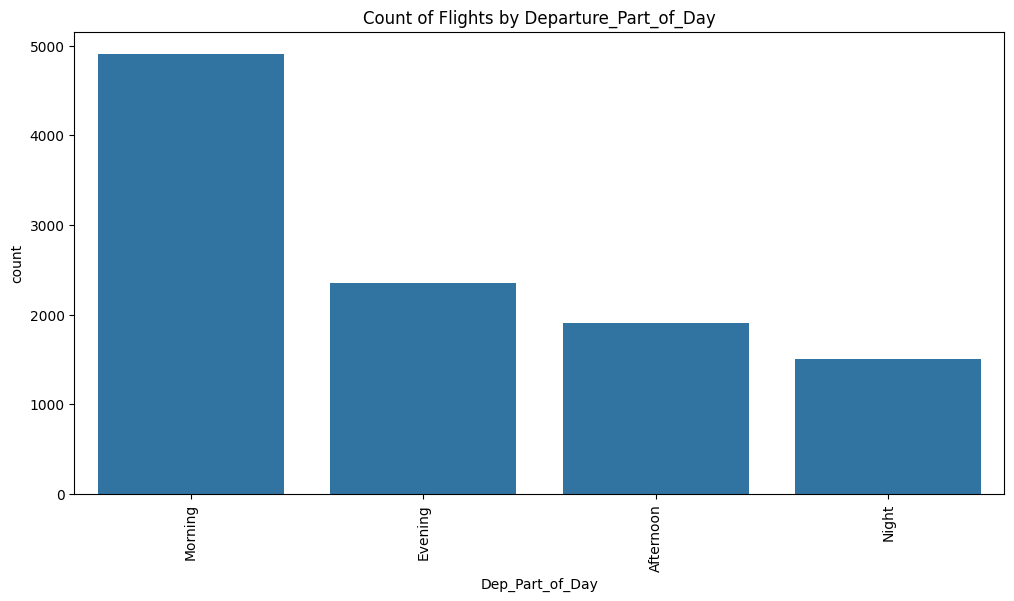

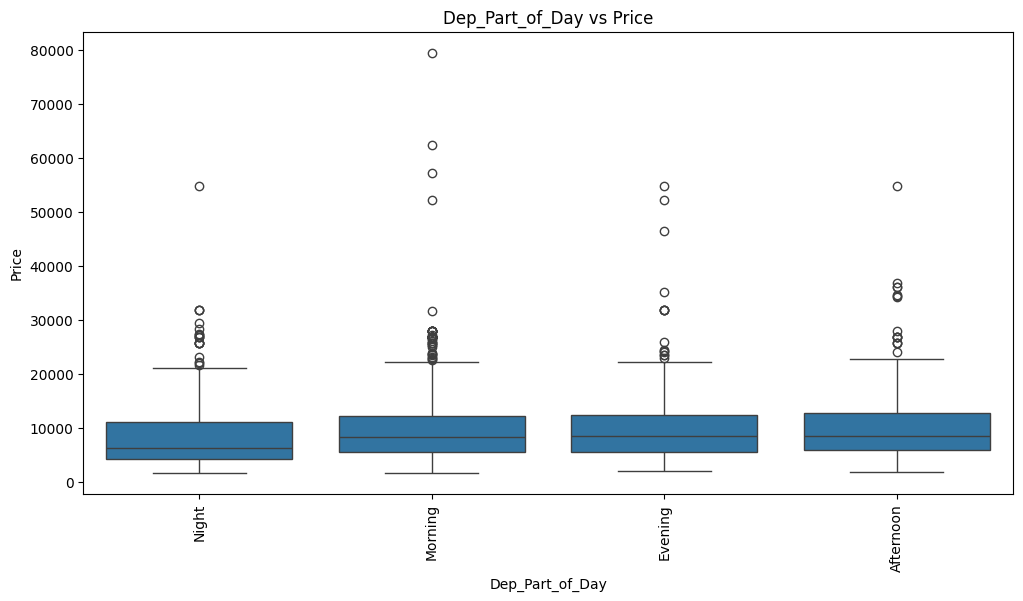

In [30]:
 #Dep_Part_of_Day feature distribution
plt.figure(figsize=(12, 6))
sns.countplot(data=train_data, x='Dep_Part_of_Day', order=train_data['Dep_Part_of_Day'].value_counts().index)
plt.title('Count of Flights by Departure_Part_of_Day')
plt.xticks(rotation=90)
plt.show()

# Dep_Part_of_Day feature dependence on Price
plt.figure(figsize=(12, 6))
sns.boxplot(data=train_data, x='Dep_Part_of_Day', y='Price',
            order=train_data.groupby('Dep_Part_of_Day')['Price'].median().sort_values().index)
plt.title('Dep_Part_of_Day vs Price')
plt.xticks(rotation=90)
plt.show()

In [31]:
train_data.drop(['Route', 'Duration', 'Dep_Hour', 'Dep_Minute', 'Arrival_Hour', 'Arrival_Minute'], axis=1, inplace=True)
test_data.drop(['Route', 'Duration', 'Dep_Hour', 'Dep_Minute', 'Arrival_Hour', 'Arrival_Minute'], axis=1, inplace=True)

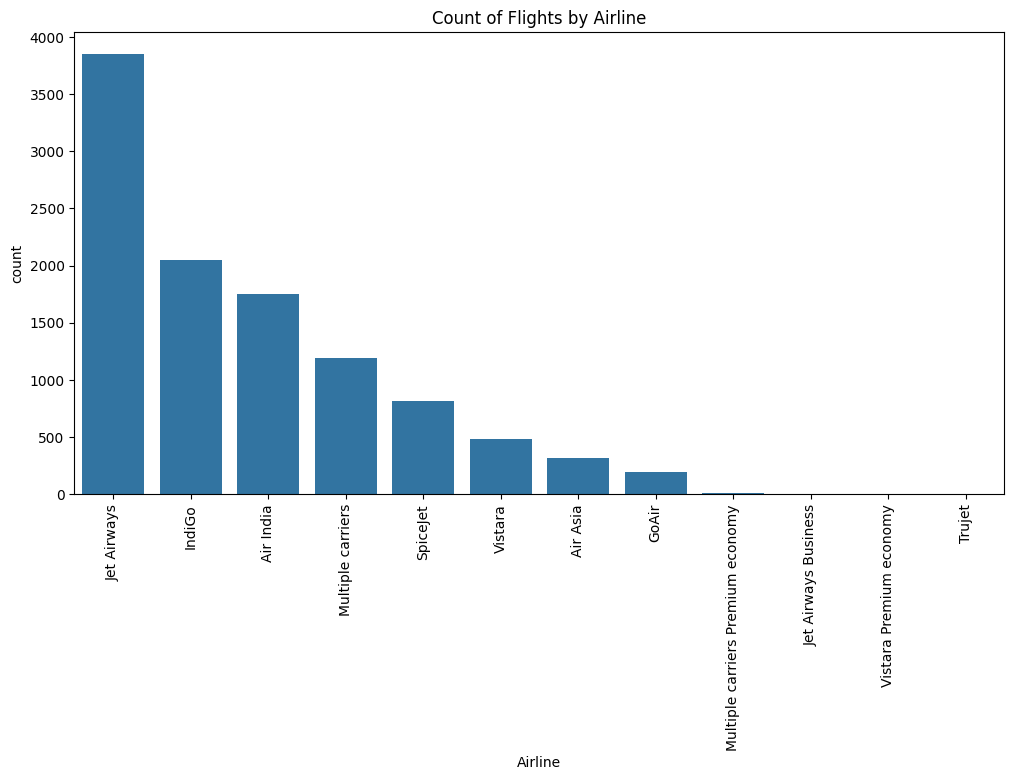

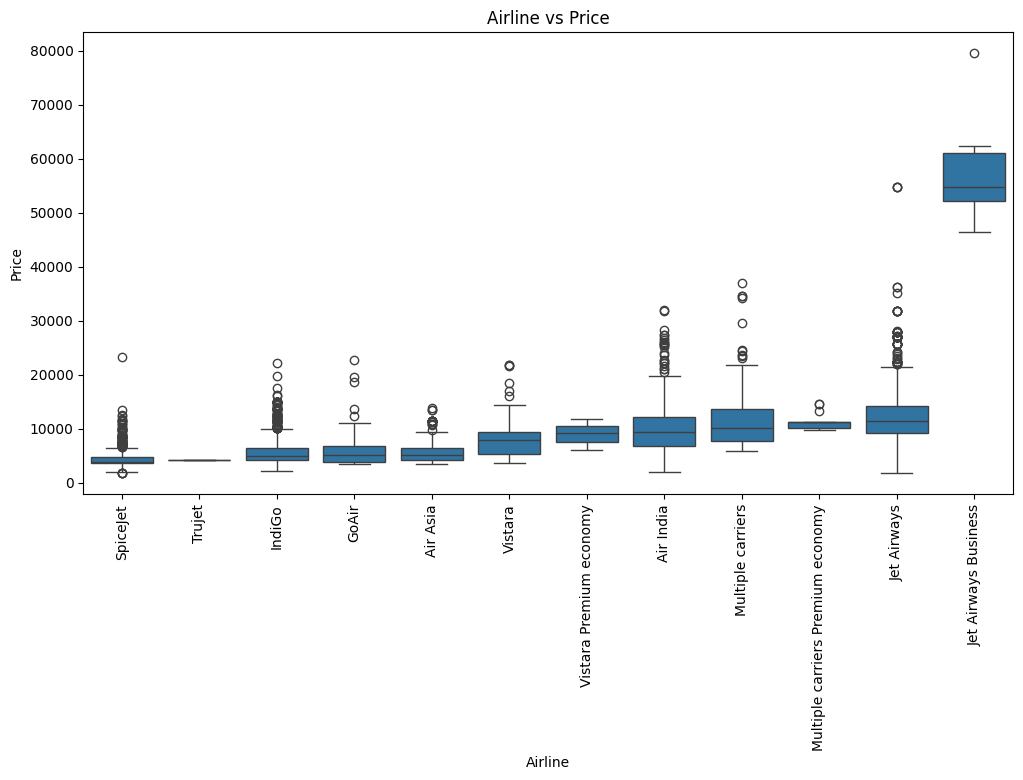

In [32]:
# Airline feature distribution
plt.figure(figsize=(12, 6))
sns.countplot(data=train_data, x='Airline', order=train_data['Airline'].value_counts().index)
plt.title('Count of Flights by Airline')
plt.xticks(rotation=90)
plt.show()

# Airline feature dependence on Price
plt.figure(figsize=(12, 6))
sns.boxplot(data=train_data, x='Airline', y='Price', order=train_data.groupby('Airline')['Price'].median().sort_values().index)
plt.title('Airline vs Price')
plt.xticks(rotation=90)
plt.show()

In [33]:
train_data.corr(numeric_only=True)

,Price,Journey_Day,Journey_Month,Journey_Day_of_Week,Is_Weekend
Price,1.000000,-0.153774,-0.103643,0.051570,0.020275
Journey_Day,-0.153774,1.000000,-0.038359,-0.091245,-0.104187
Journey_Month,-0.103643,-0.038359,1.000000,-0.083345,-0.013189
Journey_Day_of_Week,0.051570,-0.091245,-0.083345,1.000000,0.815513
Is_Weekend,0.020275,-0.104187,-0.013189,0.815513,1.000000


In [34]:
train_data['Airline'].value_counts()

Airline
Jet Airways                          3849
IndiGo                               2053
Air India                            1751
Multiple carriers                    1196
SpiceJet                              818
Vistara                               479
Air Asia                              319
GoAir                                 194
Multiple carriers Premium economy      13
Jet Airways Business                    6
Vistara Premium economy                 3
Trujet                                  1
Name: count, dtype: int64

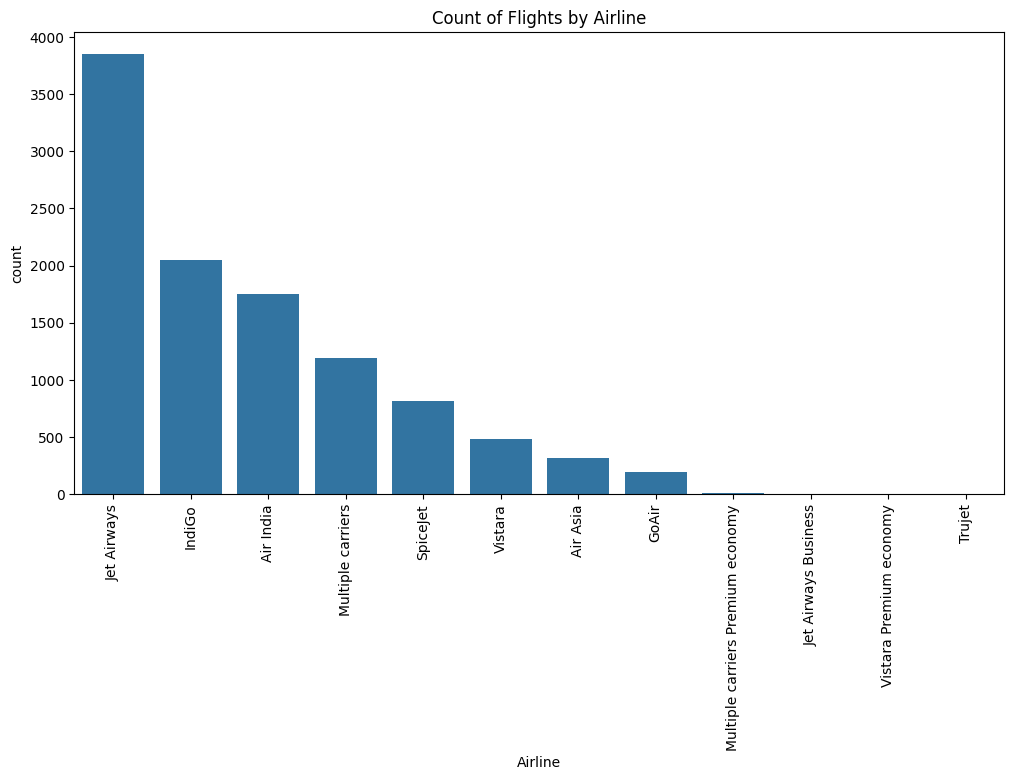

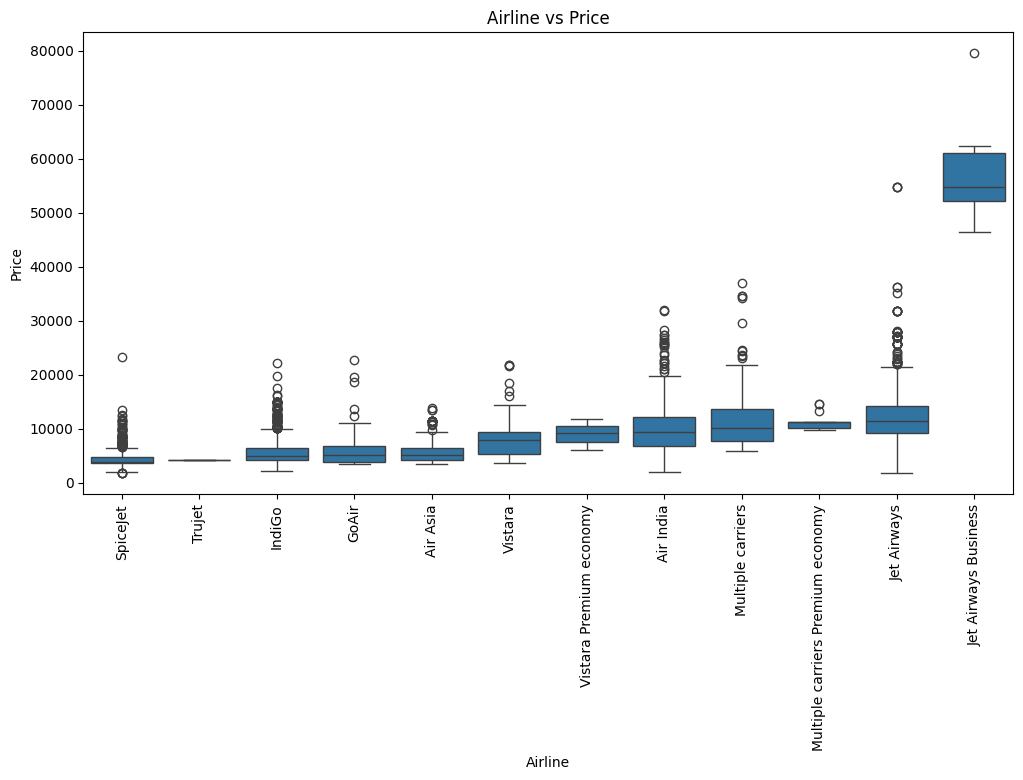

In [35]:
# Airline feature distribution
plt.figure(figsize=(12, 6))
sns.countplot(data=train_data, x='Airline', order=train_data['Airline'].value_counts().index)
plt.title('Count of Flights by Airline')
plt.xticks(rotation=90)
plt.show()

# Airline feature dependence on Price
plt.figure(figsize=(12, 6))
sns.boxplot(data=train_data, x='Airline', y='Price', order=train_data.groupby('Airline')['Price'].median().sort_values().index)
plt.title('Airline vs Price')
plt.xticks(rotation=90)
plt.show()